In [1]:
import pandas as pd
import numpy as np

In [2]:
data = {
'Order_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],

'Customer_Name': ['Amara', 'Bola', None, 'Diana', 'Efua',
                  'Fatima', 'Grace', None, 'Ifeoma', 'Joyce'],

'Country': ['Ghana', 'Nigeria', 'Kenya', None,
            'Ghana', 'Cameroon', None,
            'Kenya', 'Nigeria', 'Ghana'],

'Product': ['Laptop', 'Phone', 'Tablet',
            'Laptop', None, 'Phone',
            'Tablet', 'Laptop',
            None, 'Phone'],

'Quantity': [2,1,None,3,2,None,1,4,2,None],

'Price': [1500,800,600,1500,None,
          800,600,1500,None,800],

'Delivery_Days': [3,None,7,5,3,None,
                  6,None,4,5]
}

df = pd.DataFrame(data)

df

,Order_ID,Customer_Name,Country,Product,Quantity,Price,Delivery_Days
0,101,Amara,Ghana,Laptop,2.0,1500.0,3.0
1,102,Bola,Nigeria,Phone,1.0,800.0,NaN
2,103,None,Kenya,Tablet,NaN,600.0,7.0
3,104,Diana,None,Laptop,3.0,1500.0,5.0
4,105,Efua,Ghana,None,2.0,NaN,3.0
5,106,Fatima,Cameroon,Phone,NaN,800.0,NaN
6,107,Grace,None,Tablet,1.0,600.0,6.0
7,108,None,Kenya,Laptop,4.0,1500.0,NaN
8,109,Ifeoma,Nigeria,None,2.0,NaN,4.0
9,110,Joyce,Ghana,Phone,NaN,800.0,5.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       10 non-null     int64  
 1   Customer_Name  8 non-null      object 
 2   Country        8 non-null      object 
 3   Product        8 non-null      object 
 4   Quantity       7 non-null      float64
 5   Price          8 non-null      float64
 6   Delivery_Days  7 non-null      float64
dtypes: float64(3), int64(1), object(3)
memory usage: 692.0+ bytes


In [4]:
df.describe()

,Order_ID,Quantity,Price,Delivery_Days
count,10.00000,7.000000,8.000000,7.000000
mean,105.50000,2.142857,1012.500000,4.714286
std,3.02765,1.069045,412.093956,1.496026
min,101.00000,1.000000,600.000000,3.000000
25%,103.25000,1.500000,750.000000,3.500000
50%,105.50000,2.000000,800.000000,5.000000
75%,107.75000,2.500000,1500.000000,5.500000
max,110.00000,4.000000,1500.000000,7.000000


In [5]:
df.isnull().sum()

Order_ID         0
Customer_Name    2
Country          2
Product          2
Quantity         3
Price            2
Delivery_Days    3
dtype: int64

In [ ]:
### Task 1 Explanation

The dataset contains missing values in several columns, including Customer_Name, Country, Product, Quantity, Price, and Delivery_Days. These missing values need to be cleaned before carrying out any meaningful analysis. The Order_ID column has no missing values and can uniquely identify each order.

In [6]:
df['Customer_Name'] = df['Customer_Name'].fillna('Unknown')

In [ ]:
I filled the missing customer names with "Unknown" because the actual names cannot be recovered. This allows the records to remain in the dataset without leaving blank values.

In [7]:
df['Quantity'].median()

2.0

In [8]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [9]:
df['Price'].median()

800.0

In [ ]:
df['Price'] = df['Price'].fillna(df['Price'].median())

In [ ]:
I used the median for the Quantity column because it is less affected by extreme values than the mean.

I also used the median for the Price column because it provides a more representative value when there are possible outliers in the prices.

In [10]:
df['Delivery_Days'].describe()

count    7.000000
mean     4.714286
std      1.496026
min      3.000000
25%      3.500000
50%      5.000000
75%      5.500000
max      7.000000
Name: Delivery_Days, dtype: float64

Matplotlib is building the font cache; this may take a moment.


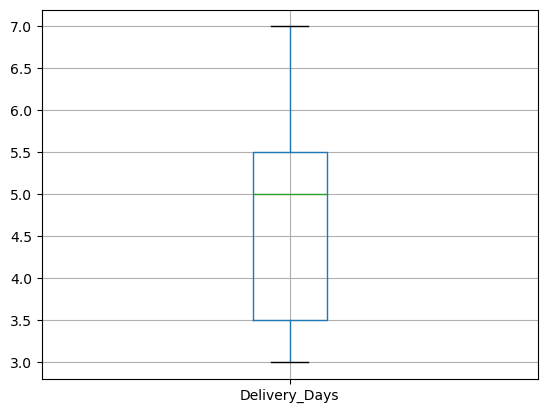

In [11]:
import matplotlib.pyplot as plt

df.boxplot(column='Delivery_Days')

plt.show()

In [12]:
df['Delivery_Days'] = df['Delivery_Days'].fillna(df['Delivery_Days'].median())

In [ ]:
The Delivery_Days values do not show significant outliers, so I used the median to replace the missing values. The median is a reliable measure of central tendency and is not influenced by unusually high or low values.

In [13]:
df['Country'].mode()

0    Ghana
Name: Country, dtype: object

In [14]:
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

In [15]:
df['Product'].mode()

0    Laptop
1     Phone
Name: Product, dtype: object

In [ ]:
df['Product'] = df['Product'].fillna(df['Product'].mode()[0])

In [ ]:
The Country column contains categorical data, so I replaced the missing values with the most frequently occurring country (mode).

The Product column is also categorical, so I filled the missing values using the mode to preserve the most common product category.

In [16]:
df.isnull().sum()

Order_ID         0
Customer_Name    0
Country          0
Product          2
Quantity         0
Price            2
Delivery_Days    0
dtype: int64

In [ ]:
### Reflection

The hardest decision was choosing the best method for replacing the missing numerical values because I had to decide between the mean and the median. I did not use the same method for every column because each type of data required a different approach. For categorical columns such as Country and Product, I used the mode, while for Customer_Name I used the value "Unknown" since the original names could not be recovered. For the numerical columns, I chose the median because it is less affected by extreme values. If 50% of the Price column had been missing, I would have investigated the cause of the missing data before filling it. Depending on the situation, I might have used more advanced imputation techniques or considered removing the column if it was too unreliable.